In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("nba-players.csv")
print(f"Dataset shape: {df.shape}")
print("\nTarget 'target_5yrs' distribution:")
print(df['target_5yrs'].value_counts(dropna=False))
df_cleaned = df.drop(columns=['name'], errors='ignore')
print(f"Shape after removing name column:  {df_cleaned.shape}")

Dataset shape: (1340, 22)

Target 'target_5yrs' distribution:
target_5yrs
1    831
0    509
Name: count, dtype: int64
Shape after removing name column:  (1340, 21)


In [4]:
print("Columns with missing values before cleaning:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"-> Filled missing entries in '{col}' with median: {median_val}")

Columns with missing values before cleaning:
Series([], dtype: int64)


In [5]:
df_cleaned['pts_per_min'] = df_cleaned['pts'] / (df_cleaned['min'] + 1e-5)
df_cleaned['box_efficiency'] = (
    df_cleaned['pts'] + df_cleaned['reb'] + df_cleaned['ast'] + df_cleaned['stl'] + df_cleaned['blk']
) - (
    (df_cleaned['fga'] - df_cleaned['fgm']) + (df_cleaned['fta'] - df_cleaned['ftm']) + df_cleaned['tov']
)
print("Engineered features 'pts_per_min' and 'box_efficiency' successfully created!")
df_cleaned[['pts_per_min', 'box_efficiency']].head()


Engineered features 'pts_per_min' and 'box_efficiency' successfully created!


,pts_per_min,box_efficiency
0,0.270073,7.2
1,0.267658,7.8
2,0.339869,5.1
3,0.491379,4.5
4,0.391304,5.2


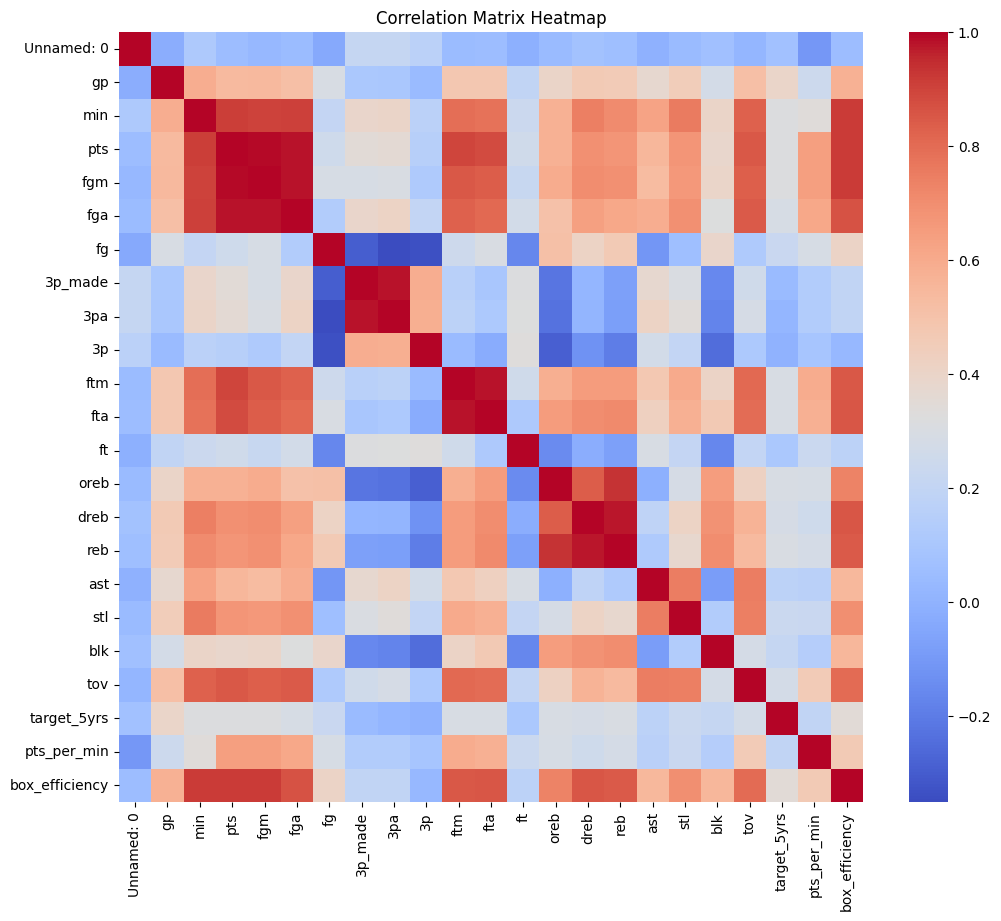

Heatmap saved to your project folder as 'correlation_heatmap.png'


In [6]:
predictors_df = df_cleaned.drop(columns=['target_5yrs'], errors='ignore')
corr_matrix = predictors_df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.savefig("correlation_heatmap.png", bbox_inches='tight')
plt.show()
print("Heatmap saved to your project folder as 'correlation_heatmap.png'")

In [7]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
if 'Unnamed: 0' in df_cleaned.columns:
    high_corr_cols.append('Unnamed: 0')
print(f"Features to drop (Redundant & Noise): {high_corr_cols}")
df_final = df_cleaned.drop(columns=high_corr_cols, errors='ignore')
print(f"\nFinal clean dataset shape: {df_final.shape}")
df_final.to_csv("clean_nba_longevity_features.csv", index=False)
print("Saved final data as 'clean_nba_longevity_features.csv'")

Features to drop (Redundant & Noise): ['pts', 'fgm', 'fga', '3pa', 'fta', 'reb', 'box_efficiency', 'Unnamed: 0']

Final clean dataset shape: (1340, 15)
Saved final data as 'clean_nba_longevity_features.csv'


### Feature Engineering Decision Summary
* **Target Variable:** 'target_5yrs' was successfully isolated to serve as our binary classification objective.
* **Noise Filters:** Removed identifiers like player names and the empty index row 'Unnamed: 0'.These columns do not have predictive value and risk causing data leakage or overfitting.
* **Missing Values:** Checked for null matrices across all performance metrics. The feaature columns were found to be 100% complete.
* **Composite Metrics Engineered:**

  1. 'pts_per_min': Capture scoring efficiency  relative to time spent on the floor, normalizing out players who simply get more minutes.
  2. 'box_efficiency': Combines volume contributions (Points, Rebounds, Assists, Steals, Blocks) and subtracts negative actions (Missed Shots, Turnovers) into a single performance index.
* **Multicollinearity Removal:** Removed highly redundant features with Pearson correlation coefficients above $0.90$ (e.g.,dropping raw volumes like 'fgm' and 'fga' in favor of rates). This reduces model variance and  ensure high interpretability.